In [1]:
%pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


# Set up database

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# PHONE SCREEN

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
query = "SELECT * FROM `SCREEN_TIME` WHERE `DEVICE`='smartphone'"
ps = pd.read_sql(query, engine)

In [5]:
ps.head()

,SCREEN_TIME_ID,USER_ID,DAY,DEVICE,SCREEN_TIME,SOCIAL
0,1,1,2025-07-18,smartphone,396.0,121.0
1,3,1,2025-07-19,smartphone,162.0,34.0
2,6,1,2025-07-20,smartphone,262.0,134.0
3,8,1,2025-07-21,smartphone,405.0,199.0
4,10,1,2025-07-22,smartphone,393.0,250.0


In [6]:
print(ps[['SCREEN_TIME','SOCIAL']].describe())

       SCREEN_TIME      SOCIAL
count    28.000000   28.000000
mean    376.928571  226.285714
std     115.746827  134.179498
min     162.000000   31.000000
25%     289.750000  118.500000
50%     386.500000  229.500000
75%     445.500000  324.000000
max     635.000000  551.000000


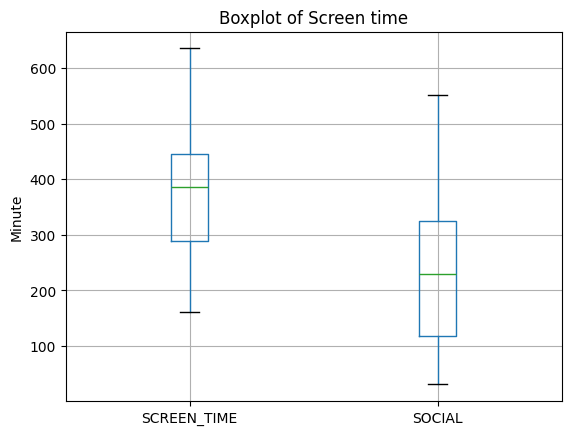

In [7]:
ps.boxplot(column=['SCREEN_TIME','SOCIAL'])

plt.title('Boxplot of Screen time')
plt.ylabel('Minute')
plt.show()

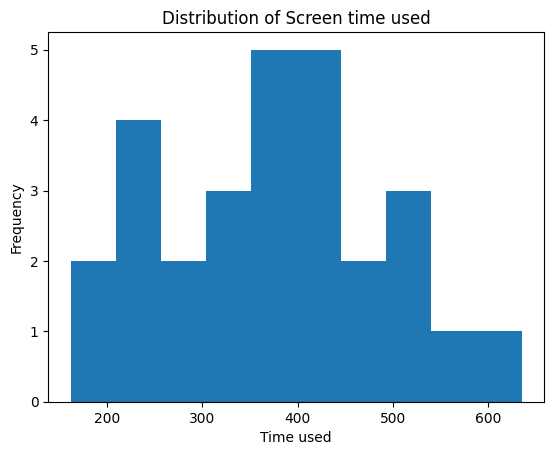

In [8]:
ps['SCREEN_TIME'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Screen time used")
plt.show()

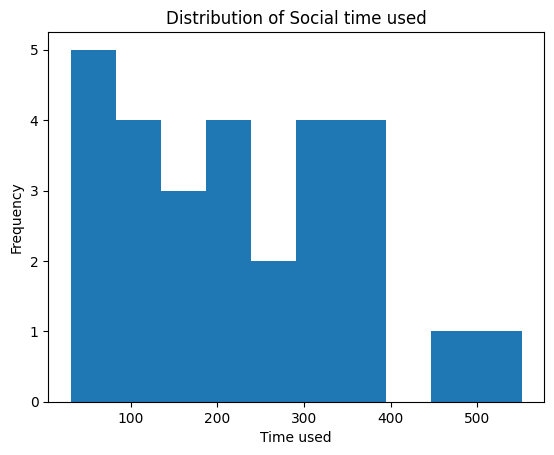

In [9]:
ps['SOCIAL'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Social time used")
plt.show()

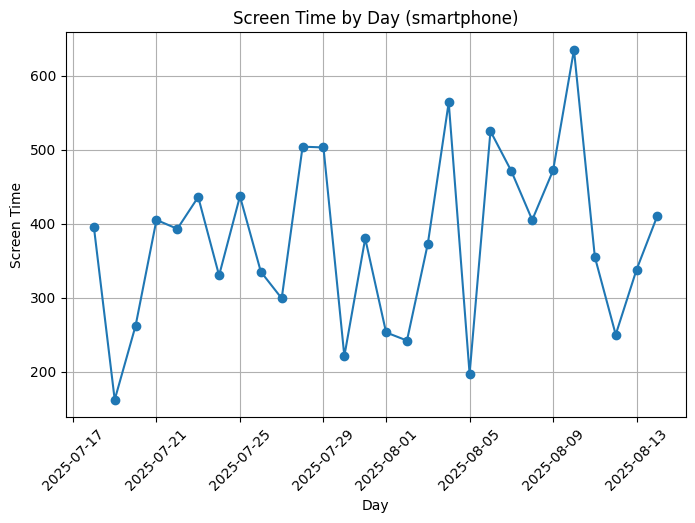

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SCREEN_TIME'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day (smartphone)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

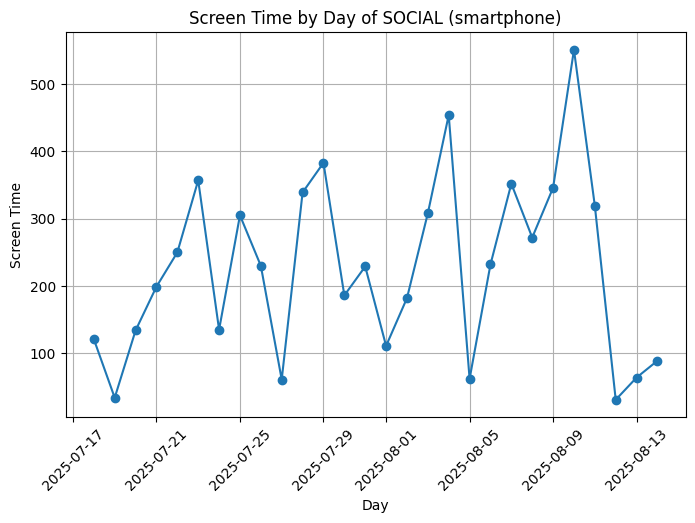

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SOCIAL'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day of SOCIAL (smartphone)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

$z$-score

In [12]:
from scipy.stats import zscore

ps['z_score of SCREEN_TIME'] = zscore(ps['SCREEN_TIME'])
ps['z_score of SOCIAL'] = zscore(ps['SOCIAL'])

ps.head()

,SCREEN_TIME_ID,USER_ID,DAY,DEVICE,SCREEN_TIME,SOCIAL,z_score of SCREEN_TIME,z_score of SOCIAL
0,1,1,2025-07-18,smartphone,396.0,121.0,0.167792,-0.799062
1,3,1,2025-07-19,smartphone,162.0,34.0,-1.890959,-1.459345
2,6,1,2025-07-20,smartphone,262.0,134.0,-1.011151,-0.700399
3,8,1,2025-07-21,smartphone,405.0,199.0,0.246975,-0.207084
4,10,1,2025-07-22,smartphone,393.0,250.0,0.141398,0.179979


Chebyshev's theorem

In [13]:
z = 1.6634959668526281
print(1-(1/(z*z)))

0.6386263390044107
